In [ ]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 23.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=3f87e4fea7472935821f3a29214e816f0835f153746f3f8a68fc20eece50855c
  Stored in directory: /root/.cache/pip/wheels/56/8b/41/7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize-matplotlib


① 試験の得点分布を可視化するために，ヒストグラムを描くことにした

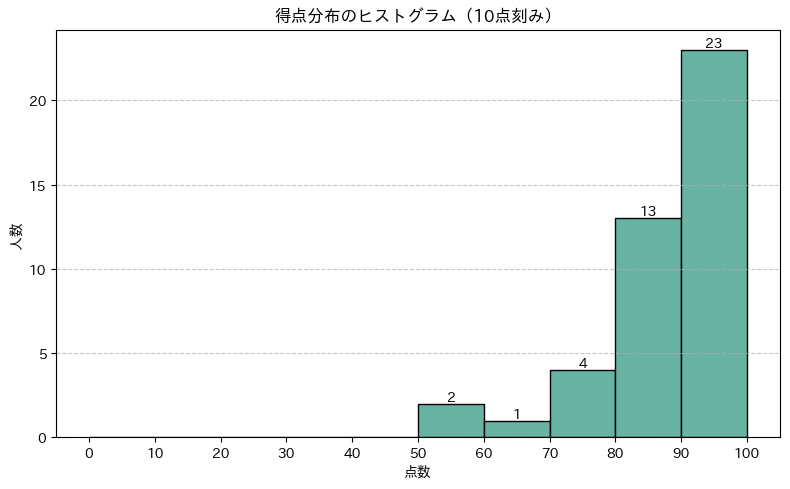

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# データ
scores = [96, 90, 97, 51, -1, 88, 55, 100, 88, 100, 90, 100, 88, 98, 100,
          94, 100, 90, 73, 83, 74, 72, 86, 86, 67, 100, 82, 100, 100, 82,
          81, 73, 97, 100, 88, 84, 96, 94, 99, 100, 100, 88, 94, 88]

# 外れ値（-1など）を除外する場合
scores = [s for s in scores if 0 <= s <= 100]

# ビン（区間[0.100]内に11点を等間隔にとる）[0.10).[10,20),...,[90.100]
# 最後の区間だけ，得点の幅が11となっている点に注意する
bins = np.linspace(0, 100, 11)

# グラフの描画領域
fig, ax = plt.subplots(figsize=(8, 5))

# ヒストグラム描画（countsを受け取る）
counts, bin_edges, patches = ax.hist(
    scores,
    bins=bins,
    edgecolor='black',
    color='#69b3a2'
)

# ビンの上部に人数を表示
for count, edge_left, edge_right in zip(counts, bin_edges[:-1], bin_edges[1:]):
    x = (edge_left + edge_right) / 2  # ビンの中央
    if count > 0:
        ax.text(x, count, f'{int(count)}',
                ha='center', va='bottom', fontsize=10)

# 見た目調整
ax.set_xticks(bins)
ax.set_xlabel('点数')
ax.set_ylabel('人数')
ax.set_title('得点分布のヒストグラム（10点刻み）')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# fig.savefig('./out/histogram.png')
plt.show()

② 100点満点の学生数を表示するために，最も右のビンの上部へその数値を色を付けて表示することにした．

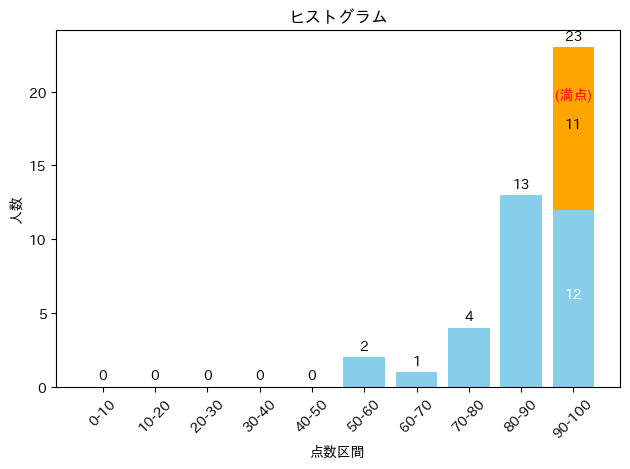

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# サンプルデータ（実際はここを差し替え）
np.random.seed(0)
scores = [96, 90, 97, 51, -1, 88, 55, 100, 88, 100, 90, 100, 88, 98, 100,
          94, 100, 90, 73, 83, 74, 72, 86, 86, 67, 100, 82, 100, 100, 82,
          81, 73, 97, 100, 88, 84, 96, 94, 99, 100, 100, 88, 94, 88]


# 0〜100を10区間
bins = np.linspace(0, 100, 11)
counts, edges = np.histogram(scores, bins=bins)

fig, ax = plt.subplots()

# --- 通常ビン ---
for i in range(len(counts) - 1):
    ax.bar([i], [counts[i]], color="skyblue")
    ax.text(i, counts[i] + 0.5, str(counts[i]), ha='center')

# --- 最後のビン（90–100）を分解 ---
last_low = len([x for x in scores if 90 <= x and x <= 99])  # 90-99
last_high = len([x for x in scores if x == 100])                # 100
total_last = last_low + last_high

x = len(counts) - 1

# 下部（90–99点）
ax.bar([x], [last_low], color="skyblue")

# 上部（100点）←積み上げ
ax.bar([x], [last_high], bottom=[last_low], color="orange")

# --- 内部ラベル ---
ax.text(x, last_low / 2, str(last_low), ha='center', color='white')      # 下部
if last_high > 0:
    ax.text(x, last_low + last_high / 2, str(last_high), ha='center')    # 上部
    ax.text(x, last_low + last_high / 2 + 2, f"(満点)", ha='center',  color='red')    # 上部

# --- 上端に合計 ---
ax.text(x, total_last + 0.5, str(total_last), ha='center')

# 軸設定
ax.set_xticks(range(len(edges) - 1))
ax.set_xticklabels([f"{int(edges[i])}-{int(edges[i+1])}" for i in range(len(edges) - 1)], rotation=45)

ax.set_xlabel("点数区間")
ax.set_ylabel("人数")
ax.set_title("ヒストグラム")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.rcParams['font.family'] = 'IPAexGothic'

# データ読み込み
df = pd.read_excel("examdata.xlsx", engine="openpyxl")

years = df.columns
data = [df[y].dropna().values for y in years]

# 外れ値除外で統計量
def calc_stats_no_outlier(values):
    # 各四分位数を求める
    q1 = np.percentile(values, 25)
    q2 = np.percentile(values, 50)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    filtered = values[(values >= lower) & (values <= upper)]

    return {
        "min": np.min(filtered),
        "q1": q1,
        "q2": q2,
        "q3": q3,
        "max": np.max(filtered)
    }

stats_list = [calc_stats_no_outlier(v) for v in data]

# 描画
fig, ax = plt.subplots(figsize=(10,6))
box = ax.boxplot(
    data,
    tick_labels=[f"{y}年度" for y in years], #Matplotlib 3.9以降では labels → tick_labels に変更されています。
    patch_artist=True,
    showfliers=False
)

# 色
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# ✅ 凡例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors[i], label=f"{years[i]}年度")
    for i in range(len(years))
]
ax.legend(handles=legend_elements)

# ✅ ここが修正ポイント（y座標を値に対応させる）
for i, stats in enumerate(stats_list):
    x = i + 1.25  # 横に少しずらす

    ax.text(x, stats['max'], f"max:{stats['max']:.1f}", fontsize=8, va='bottom')
    ax.text(x, stats['q3'],  f"Q3:{stats['q3']:.1f}", fontsize=8, va='center')
    ax.text(x, stats['q2'],  f"中央:{stats['q2']:.1f}", fontsize=8, va='center')
    ax.text(x, stats['q1'],  f"Q1:{stats['q1']:.1f}", fontsize=8, va='center')
    ax.text(x, stats['min'], f"min:{stats['min']:.1f}", fontsize=8, va='top')

# グリッド
ax.grid(True, linestyle='--', alpha=0.7)

# ラベル
ax.set_title("年度別 得点分布（箱ひげ図）")
ax.set_ylabel("得点")

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'examdata.xlsx'